# 03. Dynamic Nelson-Siegel: yield-curve factors, forecasting, and recession signal

**Questions.**
1. Can three factors (level, slope, curvature) summarise the US Treasury curve with small errors?
2. Do forecasts built on those factors (Diebold-Li) beat a random walk for yields out of sample?
3. Does the slope carry information about recessions 12 months ahead (Estrella-Mishkin)?

**Method.** Diebold-Li (2006) with the decay parameter fixed at 0.0609 (maturities in months), factors estimated by OLS month by month.
Forecasts are *direct* h-step regressions of each factor on its own lag (AR) or on all three lags (VAR), expanding window from 2005.

**Data.** US Treasury constant-maturity yields (FRED, daily, month-end value), 1994-2026.

**Limits.** Constant-maturity yields are interpolated by the Treasury, not raw bond prices. The recession sample contains only three episodes (2001, 2008-09, 2020), so out-of-sample evidence is thin.

In [1]:
import sys, warnings
sys.path.insert(0, "src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import roc_auc_score
from data_utils import fred
from IPython.display import display
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25})

## 1. Data

1994-01-31 -> 2026-09-30 (393, 9)


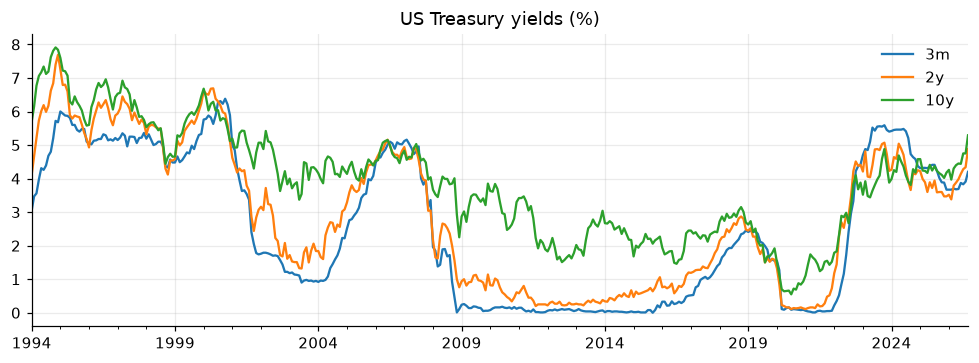

In [2]:
MAT = {"DGS3MO": 3, "DGS6MO": 6, "DGS1": 12, "DGS2": 24, "DGS3": 36, "DGS5": 60, "DGS7": 84, "DGS10": 120, "DGS20": 240}
daily = pd.concat([fred(k) for k in MAT], axis=1)
Y = daily.resample("ME").last().loc["1994-01":]
Y = Y.dropna()
Y.columns = list(MAT.values())
print(Y.index[0].date(), "->", Y.index[-1].date(), Y.shape)

fig, ax = plt.subplots(figsize=(9, 3.4))
for m in (3, 24, 120): Y[m].plot(ax=ax, label=f"{m}m" if m < 24 else f"{m//12}y")
ax.legend(frameon=False); ax.set_title("US Treasury yields (%)"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig("figures/03_yields.png"); plt.show()

## 2. Nelson-Siegel factors

In-sample fit error (bp), by maturity (months):


,3,6,12,24,36,60,84,120,240
mean,-8.1,3.0,7.2,6.4,-0.6,-7.6,-6.2,-7.7,13.6
RMSE,10.4,5.5,10.4,7.8,3.5,9.6,8.7,9.6,15.4


corr(level, 10y)        : 0.961
corr(-slope, 10y - 3m)  : 0.995
corr(curv, 2*2y-3m-10y) : 0.986


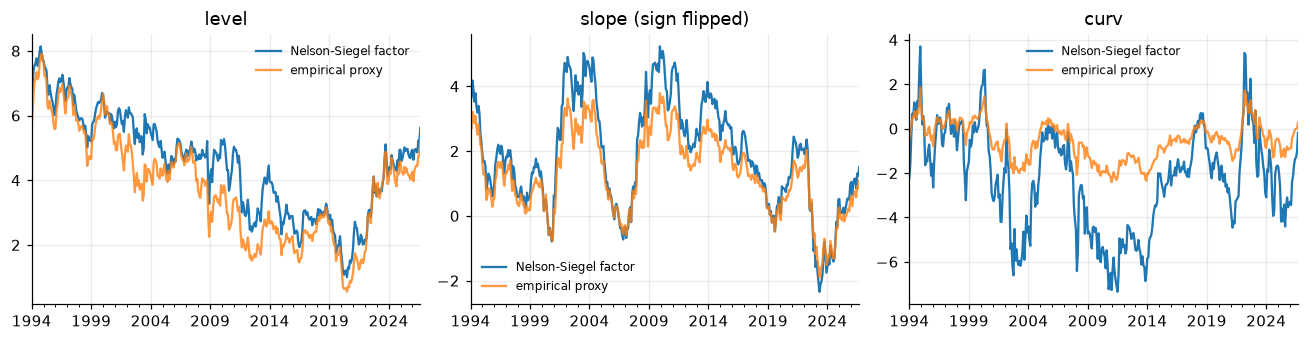

In [3]:
LAM = 0.0609
def loadings(tau, lam=LAM):
    x = lam * np.asarray(tau, float)
    l2 = (1 - np.exp(-x)) / x
    return np.column_stack([np.ones_like(x), l2, l2 - np.exp(-x)])

B = loadings(list(MAT.values()))
fac = pd.DataFrame([np.linalg.lstsq(B, Y.loc[t].values, rcond=None)[0] for t in Y.index], index=Y.index, columns=["level", "slope", "curv"])
fit = pd.DataFrame(fac.values @ B.T, index=Y.index, columns=Y.columns)
err_bp = (Y - fit) * 100
print("In-sample fit error (bp), by maturity (months):")
display(pd.DataFrame({"mean": err_bp.mean(), "RMSE": np.sqrt((err_bp ** 2).mean())}).round(1).T)

# DL's slope factor has the opposite sign to 10y-3m
emp = pd.DataFrame({"level": Y[120], "slope": Y[120] - Y[3], "curv": 2 * Y[24] - Y[3] - Y[120]})
print("corr(level, 10y)        :", round(fac.level.corr(emp.level), 3))
print("corr(-slope, 10y - 3m)  :", round((-fac.slope).corr(emp.slope), 3))
print("corr(curv, 2*2y-3m-10y) :", round(fac.curv.corr(emp.curv), 3))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, c, e, sg in zip(axes, ["level", "slope", "curv"], ["level", "slope", "curv"], [1, -1, 1]):
    (sg * fac[c]).plot(ax=ax, label="Nelson-Siegel factor"); emp[e].plot(ax=ax, label="empirical proxy", alpha=.8)
    ax.set_title(c + (" (sign flipped)" if sg < 0 else "")); ax.legend(frameon=False, fontsize=8); ax.set_xlabel("")
plt.tight_layout(); plt.savefig("figures/03_factors.png"); plt.show()

## 3. Out-of-sample forecasting of yields
Benchmarks: random walk (RW) and a direct AR(1) fitted on each yield itself. Candidates: DL-AR (factors forecast one by one) and DL-VAR (all three factors jointly).
Metric: RMSE in basis points; significance by Diebold-Mariano vs RW with HAC variance and HLN correction.

In [4]:
HZ = [1, 6, 12]
TEST_START = pd.Timestamp("2005-01-31")
TARGETS = [3, 24, 120]
Fv = fac.copy()

def direct_fc(X, Ytarget, xnew, ridge=0.0):
    A = np.column_stack([np.ones(len(X)), X])
    coef = np.linalg.lstsq(A, Ytarget, rcond=None)[0]
    return np.concatenate([[1], xnew]) @ coef

def run(h):
    rows = []
    idx = Y.index
    for i, t in enumerate(idx):
        if t < TEST_START or i + h >= len(idx): continue
        j = i - h                          # last training predictor index whose target (j+h) is known at t
        tr = np.arange(0, j + 1)
        f_hat = {"RW": None}
        # factor forecasts, direct regressions: fac[s+h] on fac[s], s in tr
        ar = np.array([direct_fc(Fv.iloc[tr][[c]].values, Fv.iloc[tr + h][c].values, Fv.iloc[i][[c]].values) for c in Fv.columns])
        var = np.array([direct_fc(Fv.iloc[tr].values, Fv.iloc[tr + h][c].values, Fv.iloc[i].values) for c in Fv.columns])
        for m in TARGETS:
            k = list(Y.columns).index(m); b = B[k]
            yar = direct_fc(Y.iloc[tr][[m]].values, Y.iloc[tr + h][m].values, Y.iloc[i][[m]].values)
            rows.append({"date": t, "mat": m, "actual": Y.iloc[i + h][m], "RW": Y.iloc[i][m], "AR(yield)": yar,
                         "DL-AR": b @ ar, "DL-VAR": b @ var})
    return pd.DataFrame(rows)

RES = {h: run(h) for h in HZ}

def dm(e0, e1, h):
    d = e0 ** 2 - e1 ** 2; n = len(d); dbar = d.mean()
    g = [np.mean((d - dbar)[k:] * (d - dbar)[:n - k]) for k in range(h)]
    v = (g[0] + 2 * sum(g[1:])) / n
    t = dbar / np.sqrt(v) * np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    return 1 - stats.t.cdf(t, n - 1)

rows = []
for h in HZ:
    for m in TARGETS:
        d = RES[h][RES[h].mat == m]
        e = {c: (d[c] - d["actual"]).values * 100 for c in ["RW", "AR(yield)", "DL-AR", "DL-VAR"]}
        row = {"h": h, "yield": f"{m}m" if m < 24 else f"{m // 12}y", "RW RMSE (bp)": round(np.sqrt((e["RW"] ** 2).mean()), 1)}
        for c in ["AR(yield)", "DL-AR", "DL-VAR"]:
            p = dm(e["RW"], e[c], h)
            row[c] = f"{np.sqrt((e[c] ** 2).mean()) / np.sqrt((e['RW'] ** 2).mean()):.2f}" + ("***" if p < .01 else "**" if p < .05 else "*" if p < .10 else "")
        rows.append(row)
tab = pd.DataFrame(rows).set_index(["h", "yield"])
print("Ratio to random-walk RMSE (<1 = beats RW); stars = one-sided DM significance. Test sample: 2005 onward.")
tab.to_csv("data/out_03_forecast_table.csv"); tab

Ratio to random-walk RMSE (<1 = beats RW); stars = one-sided DM significance. Test sample: 2005 onward.


RW RMSE (bp) AR(yield) DL-AR DL-VAR
h  yield                                     
1  3m             20.9      1.00  1.17   1.01
   2y             22.8      1.00  1.08   1.11
   10y            24.8      1.00  1.01   1.00
6  3m             80.0      1.01  1.12   0.94
   2y             71.4      1.02  1.14   1.07
   10y            61.2      1.02  1.05   1.05
12 3m            140.2      1.02  1.13   0.99
   2y            115.1      1.03  1.17   1.11
   10y            82.5      1.05  1.12   1.13

The same ratios by sub-period (forecast origins in 2005-2019 and from 2020). They are not tested: the second period has 69 to 80 forecast origins, depending on the horizon.

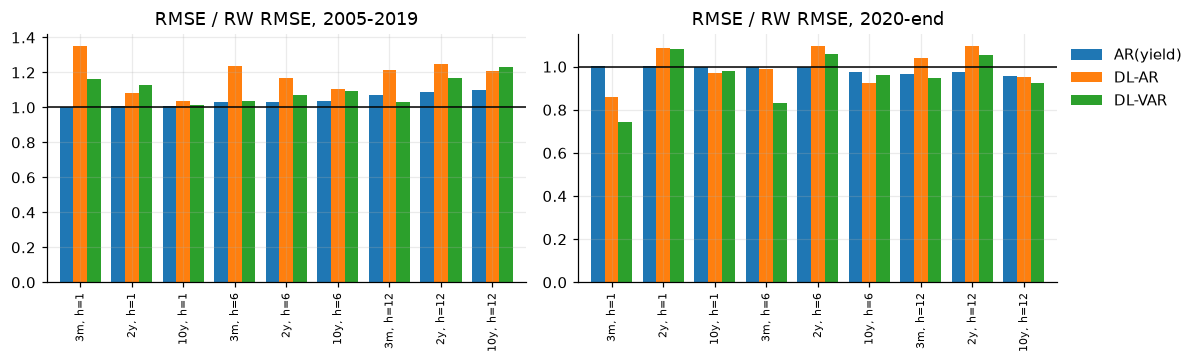

2005-2019               2020-end             
          AR(yield) DL-AR DL-VAR AR(yield) DL-AR DL-VAR
3m, h=1        1.00  1.35   1.16      1.00  0.86   0.74
2y, h=1        1.01  1.08   1.13      1.00  1.09   1.08
10y, h=1       1.01  1.04   1.02      1.00  0.97   0.98
3m, h=6        1.03  1.24   1.04      1.00  0.99   0.83
2y, h=6        1.03  1.17   1.07      1.00  1.10   1.06
10y, h=6       1.04  1.11   1.09      0.98  0.92   0.96
3m, h=12       1.07  1.21   1.03      0.97  1.04   0.95
2y, h=12       1.09  1.25   1.17      0.98  1.10   1.05
10y, h=12      1.10  1.21   1.23      0.96  0.95   0.92

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4)); SUB = {}
for ax, (a, b) in zip(axes, [(2005, 2019), (2020, 2030)]):
    vals = {}
    for h in HZ:
        for m in TARGETS:
            d = RES[h][(RES[h].mat == m) & (RES[h].date.dt.year.between(a, b))]
            e0 = np.sqrt(((d.RW - d.actual) ** 2).mean())
            vals[f"{m if m < 24 else m // 12}{'m' if m < 24 else 'y'}, h={h}"] = [np.sqrt(((d[c] - d.actual) ** 2).mean()) / e0 for c in ["AR(yield)", "DL-AR", "DL-VAR"]]
    name = f"{a}-{b if b < 2030 else 'end'}"; SUB[name] = pd.DataFrame(vals, index=["AR(yield)", "DL-AR", "DL-VAR"]).T
    SUB[name].plot.bar(ax=ax, width=.8, legend=ax is axes[1]); ax.axhline(1, color="k", lw=1)
    ax.set_title(f"RMSE / RW RMSE, {name}"); ax.tick_params(axis="x", labelsize=7)
axes[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.savefig("figures/03_forecast_rmse.png", bbox_inches="tight"); plt.show()
sub = pd.concat(SUB, axis=1).round(2); sub.to_csv("data/out_03_forecast_subperiods.csv"); sub

## 4. Macro link: slope and recessions
Estrella-Mishkin probit/logit: NBER recession indicator in month *t* on the 10y-3m slope observed in month *t-12*.
We estimate in-sample and then re-estimate on an expanding window from 2004 and compute the out-of-sample AUC (area under the ROC curve; 0.5 = coin flip).

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9561      0.221     -8.866      0.000      -2.388      -1.524
slope_l12     -0.5955      0.167     -3.556      0.000      -0.924      -0.267
Share of months in recession: 0.076 | in-sample AUC: 0.724
Out-of-sample AUC (2004-): 0.496 | n = 272 | recession months: 20


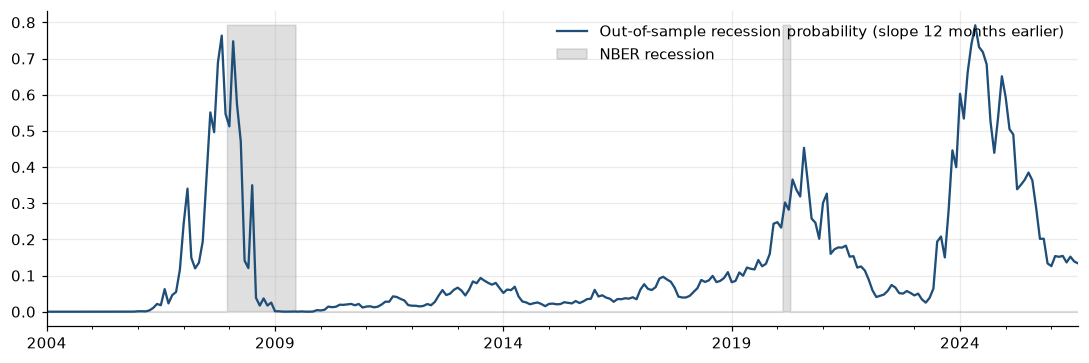

In [6]:
rec = fred("USREC"); rec.index = rec.index.to_period("M").to_timestamp("M")
sl = emp["slope"]
D = pd.concat([rec.rename("rec"), sl.shift(12).rename("slope_l12"), (fac.level - fac.level.shift(12)).shift(12).rename("dlevel_l12")], axis=1).dropna()
D = D.loc["1995":]
m1 = sm.Logit(D.rec, sm.add_constant(D[["slope_l12"]])).fit(disp=0)
print(m1.summary().tables[1])
print("Share of months in recession:", round(D.rec.mean(), 3), "| in-sample AUC:", round(roc_auc_score(D.rec, m1.predict()), 3))

probs = []
for t in D.loc["2004":].index:
    tr = D.loc[:t - pd.offsets.MonthEnd(12)]     # recession status known 12 months before is the latest fully usable label
    if tr.rec.sum() < 5: probs.append(np.nan); continue
    mm = sm.Logit(tr.rec, sm.add_constant(tr[["slope_l12"]])).fit(disp=0)
    probs.append(float(np.asarray(mm.predict(sm.add_constant(D.loc[[t], ["slope_l12"]], has_constant="add")))[0]))
oos = pd.Series(probs, index=D.loc["2004":].index).dropna()
print("Out-of-sample AUC (2004-):", round(roc_auc_score(D.rec.loc[oos.index], oos), 3), "| n =", len(oos), "| recession months:", int(D.rec.loc[oos.index].sum()))

fig, ax = plt.subplots(figsize=(10, 3.4))
oos.plot(ax=ax, color="#1f4e79", label="Out-of-sample recession probability (slope 12 months earlier)")
ax.fill_between(D.index, 0, D.rec * oos.max(), color="grey", alpha=.25, step="mid", label="NBER recession")
ax.set_xlim(oos.index[0], oos.index[-1]); ax.legend(frameon=False, loc="upper right"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig("figures/03_recession_probability.png"); plt.show()

In [7]:
# Diagnostic: is the weak out-of-sample AUC driven by the 2022-2024 inversion, which was not followed by a recession in the sample?
r = D.rec.loc[oos.index]
for lab, sel in [("2004-2019", oos.index <= "2019-12-31"), ("2004-2021", oos.index <= "2021-12-31"), ("2004-end", oos.index == oos.index)]:
    if r[sel].nunique() == 2:
        print(f"OOS AUC {lab}: {roc_auc_score(r[sel], oos[sel]):.3f}  (recession months: {int(r[sel].sum())})")
print("Mean predicted probability, 2007 (slope inverted a year earlier):", round(oos.loc["2007"].mean(), 2))
print("Mean predicted probability, 2023-2024 (inversion, no recession):", round(oos.loc["2023":"2024"].mean(), 2))
print("Recession months in the sample after 2021:", int(r.loc["2022":].sum()))

OOS AUC 2004-2019: 0.539  (recession months: 18)
OOS AUC 2004-2021: 0.552  (recession months: 20)
OOS AUC 2004-end: 0.496  (recession months: 20)
Mean predicted probability, 2007 (slope inverted a year earlier): 0.38
Mean predicted probability, 2023-2024 (inversion, no recession): 0.4
Recession months in the sample after 2021: 0


## 5. Reading guide
- The in-sample fit table shows how well three factors summarise nine maturities; large errors at the 3-month point would signal front-end misfit around policy changes.
- In the forecasting table, compare every block to the random walk first. A ratio near 1 is the usual outcome at short horizons; read the stars before the point estimate.
- The AUC is based on only three recessions: it is a signal check, not a trading rule.

**Extensions.** State-space (Kalman) Dynamic Nelson-Siegel with joint estimation, an affine no-arbitrage version (Christensen-Diebold-Rudebusch), adding macro factors to the factor VAR, and the euro-area AAA curve from the ECB.